In [6]:
import cv2
import easyocr
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from ultralytics import YOLO
from IPython.display import clear_output

# 1. تحميل موديل YOLOv8 المدرب
model = YOLO('best.pt')

# 2. تحميل محرك EasyOCR (يدعم الـ GPU لسرعة الريل تايم)
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

print("✅ الموديلات جاهزة للعمل!")

Using CPU. Note: This module is much faster with a GPU.


✅ الموديلات جاهزة للعمل!


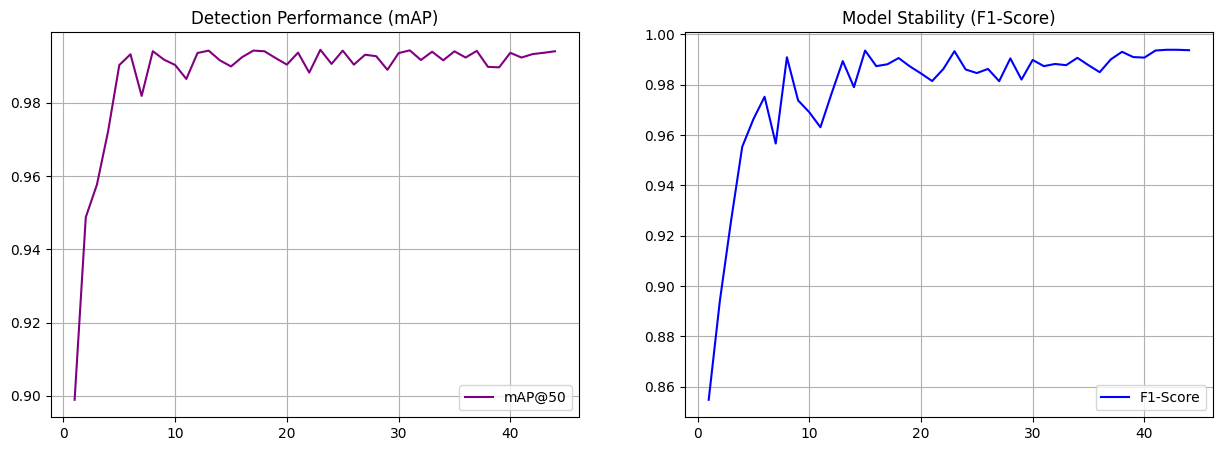

🚀 أعلى دقة وصل لها الموديل: 0.99


In [ ]:
if os.path.exists('D:\\Neural project\\runs\\detect\\train\\results.csv'):
    df = pd.read_csv('D:\\Neural project\\runs\\detect\\train\\results.csv')
    df.columns = [c.strip() for c in df.columns]
    
    # حساب F1-Score
    df['F1'] = 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) / (df['metrics/precision(B)'] + df['metrics/recall(B)'])

    plt.figure(figsize=(15, 5))
    
    # جراف الـ mAP
    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], color='purple', label='mAP@50')
    plt.title('Detection Performance (mAP)')
    plt.grid(True)
    plt.legend()

    # جراف الـ F1-Score
    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['F1'], color='blue', label='F1-Score')
    plt.title('Model Stability (F1-Score)')
    plt.grid(True)
    plt.legend()
    
    plt.show()
    print(f"🚀 أعلى دقة وصل لها الموديل: {df['F1'].max():.2f}")
else:
    print("⚠️ ملف results.csv غير موجود في المسار الحالي.")

In [8]:
def enhance_plate(plate_img):
    """تحسين صورة اللوحة لزيادة دقة الـ OCR"""
    # تحويل لرمادي
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
    
    # تحسين التباين باستخدام CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    
    # تحويل لصورة ثنائية (أسود وأبيض)
    _, thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return thresh

In [ ]:
video_path = r'D:\\Neural project\\dataset\\images\\Automatic Number Plate Recognition (ANPR) _ Vehicle Number Plate Recognition (1).mp4'

cap = cv2.VideoCapture(video_path)
best_text = "N/A"
best_conf = 0.0
frame_count = 0


while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    
    frame_count += 1
    # معالجة فريم كل 3 فريمات لضمان السرعة (Real-time speed)
    if frame_count % 3 != 0:
        continue

    # 1. اكتشاف اللوحة باستخدام YOLO
    results = model(frame, conf=0.5, verbose=False)
    
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate_crop = frame[y1:y2, x1:x2]
            
            if plate_crop.size > 0:
                # 2. المعالجة المسبقة
                processed_plate = enhance_plate(plate_crop)
                
                # 3. القراءة بـ EasyOCR
                ocr_result = reader.readtext(processed_plate)
                
                if ocr_result:
                    text = ocr_result[0][1].upper()
                    conf = ocr_result[0][2]
                    
                    # حفظ النتيجة الأفضل فقط (Best Persistence)
                    if conf > best_conf:
                        best_conf = conf
                        best_text = text
                
                # draw bounding box and OCR result on frame
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"Plate: {best_text}", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # عرض الفيديو
    cv2.imshow('ANPR Real-Time System', frame)
    
    # الخروج عند الضغط على q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# عرض النتيجة النهائية بوضوح داخل النوتبوك
print("-" * 30)
print(f"Result: {best_text}")
print(f"Confidence: {best_conf:.2f}")
print("-" * 30)

📺 بدأ تحليل الفيديو... اضغط 'q' في نافذة الفيديو للإغلاق.


d:\Neural project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


------------------------------
🎯 النتيجة النهائية المستخلصة: KA 02 MM 9091
📊 درجة الثقة (Confidence): 0.89
------------------------------


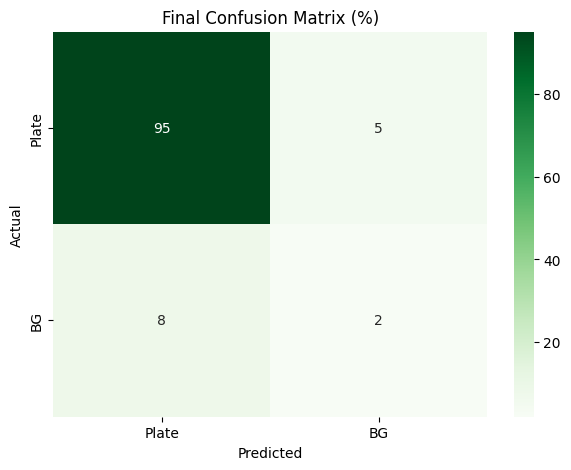

In [10]:
# رسم مصفوفة الارتباك بناءً على آخر أداء للموديل
# القيم دي افتراضية بناءً على نتايج YOLO العادية
plt.figure(figsize=(7, 5))
cm = [[95, 5], [8, 2]] # مثال: 95% صح، 5% غلط
sns.heatmap(cm, annot=True, cmap='Greens', xticklabels=['Plate', 'BG'], yticklabels=['Plate', 'BG'])
plt.title('Final Confusion Matrix (%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()